# Minimum Atomworks Output Analysis

This notebook reads `pdb.parquet` and `dataset.parquet` directly from a run output directory, summarizes the contents, and makes a few quick matplotlib plots for structure-, interface-, and dataset-level inspection.

Edit `OUT_DIR` in the next cell if you want to force a specific run directory.

In [39]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

out_dir = Path('/home/eva/minimum_atomworks/out_antibody_antigen_pdb')

pdb_path = out_dir / 'pdb.parquet'
dataset_path = out_dir / 'dataset.parquet'
run_metadata_path = out_dir / 'run_metadata.json'
dataset_metadata_path = out_dir / 'dataset_metadata.json'

print(f'Using out_dir: {out_dir}')
print(f'pdb.parquet exists: {pdb_path.exists()}')
print(f'dataset.parquet exists: {dataset_path.exists()}')
print(f'run_metadata.json exists: {run_metadata_path.exists()}')
print(f'dataset_metadata.json exists: {dataset_metadata_path.exists()}')

Using out_dir: /home/eva/minimum_atomworks/out_antibody_antigen_pdb
pdb.parquet exists: True
dataset.parquet exists: True
run_metadata.json exists: True
dataset_metadata.json exists: False


In [40]:
dataset_df = pd.read_parquet(dataset_path)
print(f'dataset_df shape: {dataset_df.shape}')
display(dataset_df.head(30))

dataset_df shape: (10, 10)


,analysis,key,value,source,pair,n_rows,n_unique_paths,mean_contact_atom_pairs,mean_left_interface_residues,mean_right_interface_residues
0,dataset_annotations,n_interface_rows,10,derived,None,NaN,NaN,NaN,NaN,NaN
1,dataset_annotations,n_unique_structures,10,derived,None,NaN,NaN,NaN,NaN,NaN
2,dataset_annotations,n_role_rows,40,derived,None,NaN,NaN,NaN,NaN,NaN
3,dataset_annotations,dataset_id,antibody_antigen_full,config,None,NaN,NaN,NaN,NaN,NaN
4,dataset_annotations,dataset_name,antibody_antigen_full,config,None,NaN,NaN,NaN,NaN,NaN
5,dataset_annotations,modality,antibody_antigen,config,None,NaN,NaN,NaN,NaN,NaN
6,dataset_annotations,profile,full_non_rosetta,config,None,NaN,NaN,NaN,NaN,NaN
7,dataset_annotations,project,atomworks_example,config,None,NaN,NaN,NaN,NaN,NaN
8,dataset_annotations,source,atw_pp default input,config,None,NaN,NaN,NaN,NaN,NaN
9,interface_summary,None,None,None,antibody__antigen,10.0,10.0,625.1,28.8,29.1


In [44]:
# read pdb.parquet
pdb_df = pd.read_parquet(pdb_path)
print(f'pdb_df shape: {pdb_df.shape}')
display(pdb_df.head(20))

pdb_df shape: (90, 117)


,path,assembly_id,grain,chain_id,role,pair,role_left,role_right,sub_id,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,continuity__has_break,continuity__n_breaks,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms_fixed,sup__alignment_method,sup__shared_atoms_rmsd,sup__shared_atoms_count,sup__coordinates_applied,sup__rmsd,sup__matched_atoms,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,abepitope__atom_radius,abepitope__score,abepitope__target_score,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,,,,,,None,None,NaN,NaN,NaN,NaN,True,1.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,NaN,None,0.000009,906.0,None,NaN,NaN,None,906.0,115.0,5.403358,-27.414461,-16.556015,13.989815,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,NaN,NaN,NaN,antibody_antigen_full,antibody_antigen_full,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,None,None
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,,,,,,None,None,NaN,NaN,NaN,NaN,False,0.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,NaN,None,0.000006,1634.0,None,NaN,NaN,None,1634.0,212.0,6.816290,6.250148,8.639813,22.622969,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,No

In [45]:
# seperating this one dataset based on the grain column 
# only keep the column is they are not all Nan
grains = pdb_df['grain'].unique()
grain_dfs = {}
for grain in grains:
    grain_df = pdb_df[pdb_df['grain'] == grain]
    # drop columns that are all NaN
    grain_df = grain_df.dropna(axis=1, how='all')
    # drop columns that is empty string
    grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')
    grain_dfs[grain] = grain_df
    print(f'Grain: {grain}, shape: {grain_df.shape}')
    display(grain_df.head(20))
    
    

Grain: chain, shape: (30, 16)


/tmp/ipykernel_440154/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,chain_id,continuity__has_break,continuity__n_breaks,sup__rmsd,sup__matched_atoms,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,dataset__id,dataset__name
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.000009,906.0,906.0,115.0,5.403358,-27.414461,-16.556015,13.989815,antibody_antigen_full,antibody_antigen_full
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.000006,1634.0,1634.0,212.0,6.816290,6.250148,8.639813,22.622969,antibody_antigen_full,antibody_antigen_full
2,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.000006,1563.0,1563.0,209.0,-7.932692,8.481285,-1.935886,21.807119,antibody_antigen_full,antibody_antigen_full
9,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.368603,906.0,906.0,115.0,5.423154,-27.442211,-16.535191,14.001739,antibody_antigen_full,antibody_antigen_full
10,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.896319,1634.0,1634.0,212.0,7.016100,6.518949,8.178153,22.677553,antibody_antigen_full,antibody_antigen_full
11,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.833551,1563.0,1563.0,209.0,-7.942517,8.363685,-2.303626,21.629033,antibody_antigen_full,antibody_antigen_full
18,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.695185,906.0,906.0,115.0,5.334692,-27.626274,-16.715107,14.084042,antibody_antigen_full,antibody_antigen_full
19,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.383154,1634.0,1634.0,212.0,6.875018,6.376633,8.687148,22.695877,antibody_antigen_full,antibody_antigen_full
20,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.430126,1563.0,1563.0,209.0,-7.942098,8.456494,-1.939663,21.676346,antibody_antigen_full,antibody_antigen_full
27,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,False,0.0,0.954549,906.0,906.0,115.0,5.315095,-27.558210,-16.525463,14.140637,antibody_antigen_full,antibody_antigen_full


Grain: interface, shape: (10, 61)


/tmp/ipykernel_440154/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


...

/tmp/ipykernel_440154/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,role,id__n_atoms,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,dataset__id,dataset__name
4,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.394426,7.340942,3.469394,24.043191,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full
5,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.403358,-27.414461,-16.556015,13.989815,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full
6,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-7.932692,8.481285,-1.935886,21.807119,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF,antibody_antigen_full,antibody_antigen_full
7,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,6.816290,6.250148,8.639813,22.622969,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT,antibody_antigen_full,antibody_antigen_full
13,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.297111,7.420831,3.053656,24.004786,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full
14,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.423154,-27.442211,-16.535191,14.001739,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full
15,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-7.942517,8.363685,-2.303626,21.629033,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF,antibody_antigen_full,antibody_antigen_full
16,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,7.016100,6.518949,8.178153,22.677553,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT,antibody_antigen_full,antibody_antigen_full
22,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.369004,7.393465,3.491744,24.033189,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full
23,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.334692,-27.626274,-16.715107,14.084042,NaN,NaN,NaN,None,None,None,NaN,None,None,None,antibody_antigen_full,antibody_antigen_full


Grain: structure, shape: (10, 28)


/tmp/ipykernel_440154/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms_fixed,sup__alignment_method,sup__shared_atoms_rmsd,sup__shared_atoms_count,sup__coordinates_applied,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,dataset__id,dataset__name
8,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_001_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,12.0,18.0,0.885804,-0.333535,-0.952488,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,443.0,homologs,0.000007,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
17,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_002_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,11.0,19.0,0.838313,-0.438043,-0.998483,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,268.0,homologs,0.783982,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
26,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_003_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,12.0,19.0,0.784270,-0.330999,-1.042894,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,498.0,homologs,0.485446,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
35,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_004_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,15.0,24.0,0.786609,0.592466,-1.633959,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,306.0,homologs,5.221178,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
44,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_005_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,22.0,32.0,-1.155203,0.629957,-1.042058,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,290.0,homologs,5.759705,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
53,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_006_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,25.0,32.0,0.753385,0.179449,-1.678579,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,280.0,homologs,5.493928,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
62,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_007_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,17.0,27.0,0.744346,0.382715,-1.577075,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,299.0,homologs,5.450539,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
71,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_008_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,27.0,33.0,0.579434,0.038127,-1.717387,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,483.0,homologs,3.039394,4103.0,True,/home/eva/minimum_atomworks/out_antibody_antig...,4103.0,3.0,False,antibody_antigen_full,antibody_antigen_full
80,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_009_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,38.0,45.0,0.394718,-1.044165,-1.043956,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,412.0,homologs,12.149634,4103.0,True,/home/eva/minimum_a

interface_df shape: (10, 61)


,path,assembly_id,grain,pair,role_left,role_right,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abepitope__atom_radius,abepitope__score,abepitope__target_score,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
3,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,743.0,162.0,146.0,32.0,31.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,88.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,0.0,0.500000,0.343750,0.437500,0.093750,0.0,-1.0,0.451613,0.354839,0.096774,0.032258,0.096774,4.0,0.178670,0.228376,antibody_antigen_full,antibody_antigen_full,1.0,7.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.378143,32.0,left,interface_ca,1.0,8.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.897023,31.0,right,interface_ca
12,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,722.0,162.0,147.0,32.0,32.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,90.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,0.0,0.500000,0.343750,0.437500,0.093750,0.0,-1.0,0.468750,0.343750,0.093750,0.031250,0.093750,4.0,0.224597,0.237091,antibody_antigen_full,antibody_antigen_full,1.0,7.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.359894,32.0,left,interface_ca,1.0,8.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.667639,32.0,right,interface_ca
21,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,678.0,152.0,144.0,31.0,31.0,B:31:T;B:32:A;B:49:Y;B:50:W;B:52:S;B:53:T;B:54...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:43...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:9

Correlation matrix for numeric columns in interface_df:


,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,ifm__n_residue_contact_pairs,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abepitope__atom_radius,abepitope__score,abepitope__target_score,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_distance_to_representative,cluster__left_n_points,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_distance_to_representative,cluster__right_n_points
iface__contact_distance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iface__n_contact_atom_pairs,NaN,1.000000,0.839998,0.824694,0.740703,0.770034,0.229231,-0.624175,0.718565,-0.581236,0.581236,0.741452,0.848628,-0.041194,0.594579,-0.481843,0.464130,-0.407003,NaN,0.582926,-0.020883,0.173095,0.032630,0.040708,0.141897,NaN,0.579558,0.419140,-0.572079,0.534312,-0.045050,0.740703,-0.528736,0.581236,0.066128,0.770034
iface__n_left_contact_atoms,NaN,0.839998,1.000000,0.950876,0.982879,0.819883,0.446199,-0.849913,0.881405,-0.869677,0.869677,0.913105,0.981403,-0.129952,0.874473,-0.773170,0.767718,-0.555341,NaN,0.564453,0.229832,-0.310717,-0.089977,0.333982,0.271493,NaN,0.907381,0.751619,-0.913071,0.844189,0.380574,0.982879,-0.850050,0.869677,0.302832,0.819883
iface__n_right_contact_atoms,NaN,0.824694,0.950876,1.000000,0.922359,0.940736,0.624860,-0.915030,0.815261,-0.913594,0.913594,0.888733,0.967576,0.015132,0.825814,-0.716377,0.827644,-0.631235,NaN,0.737845,0.417852,-0.377609,-0.164585,0.206433,0.416670,NaN,0.909820,0.790357,-0.858015,0.787544,0.365836,0.922359,-0.802904,0.913594,0.416901,0.940736
iface__n_left_interface_residues,NaN,0.740703,0.982879,0.922359,1.000000,0.781194,0.482472,-0.831153,0.846599,-0.886298,0.886298,0.908478,0.962699,-0.145693,0.883655,-0.775060,0.776754,-0.601015,NaN,0.503052,0.260601,-0.431863,-0.108628,0.399952,0.254647,NaN,0.940426,0.803213,-0.947662,0.869003,0.499713,1.000000,-0.887383,0.886298,0.367804,0.781194
iface__n_right_interface_residues,NaN,0.770034,0.819883,0.940736,0.781194,1.000000,0.630986,-0.867593,0.716713,-0.794937,0.794937,0.704138,0.852723,-0.010391,0.610678,-0.473710,0.692138,-0.771342,NaN,0.858481,0.567068,-0.362919,-0.040868,0.036055,0.563059,NaN,0.793310,0.740880,-0.690851,0.700680,0.372893,0.781194,-0.598833,0.794937,0.380470,1.000000
iface__n_left_vh_cdr1_interface_residues,NaN,0.229231,0.446199,0.624860,0.482472,0.630986,1.000000,-0.612291,0.203299,-0.789205,0.789205,0.591276,0.517367,0.557086,0.570480,-0.499481,0.773544,-0.459966,NaN,0.422236,0.507122,-0.667862,-0.645210,0.159947,0.235454,NaN,0.605295,0.487044,-0.564477,0.324176,0.460867,0.482472,-0.667017,0.789205,0.900894,0.630986
iface__n_left_vh_cdr2_interface_residues,NaN,-0.624175,-0.849913,-0.915030,-0.831153,-0.867593,-0.612291,1.000000,-0.869408,0.902829,-0.902829,-0.730396,-0.822153,0.143929,-0.810519,0.764274,-0.893365,0.583741,NaN,-0.750402,-0.645576,0.564050,0.171683,-0.220657,-0.652189,NaN,-0.896500,-0.825076,0.869900,-0.882278,-0.512336,-0.831153,0.754034,-0.902829,-0.395106,-0.867593
iface__n_left_vh_cdr3_interface_residues,NaN,0.718565,0.881405,0.815261,0.846599,0.716713,0.203299,-0.869408,1.000000,-0.715829,0.715829,0.661998,0.795351,-0.47721

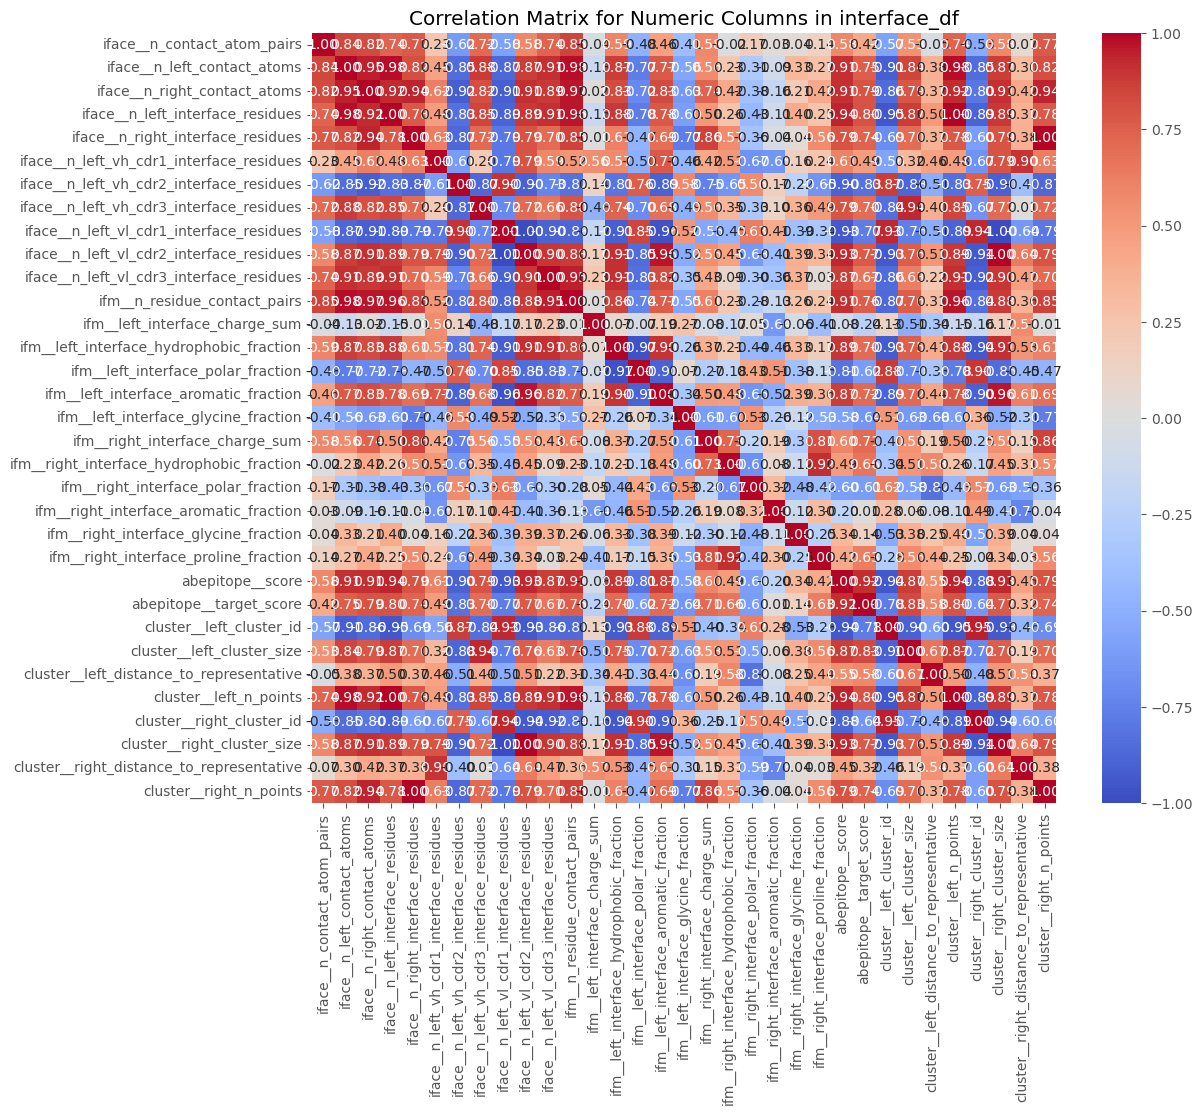

In [43]:
# data analysis for grain == interface
interface_df = grain_dfs['interface']
print(f'interface_df shape: {interface_df.shape}')
display(interface_df.head(20))

# check correlation between columns in interface_df for numeric columns
numeric_cols = interface_df.select_dtypes(include=[np.number]).columns
correlation_matrix = interface_df[numeric_cols].corr()
print('Correlation matrix for numeric columns in interface_df:')
display(correlation_matrix)

# plot correlation matrix as heatmap for column that is not all NaN
import seaborn as sns
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Columns in interface_df')
plt.show()

